# Comparación de modelos de sueño — Jhoan Saavedra

Notebook sencillo para comparar Random Forest y LightGBM usando exactamente el mismo preprocesamiento reutilizable que consumirá FastAPI. La construcción del dataset, división por sujeto, métricas y tracking viven en el paquete `sleep-staging`.

## 1. Configuración

Para una prueba rápida puede asignarse `MAX_RECORDS = 4`. Para el experimento completo debe permanecer en `None`. MLflow está desactivado por defecto.

In [17]:
from pathlib import Path
import sys

REPO_ROOT = next(path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (path / 'data.dvc').is_file())
PACKAGE_SRC = REPO_ROOT / 'packages' / 'sleep-staging' / 'src'
if str(PACKAGE_SRC) not in sys.path:
    sys.path.insert(0, str(PACKAGE_SRC))

from IPython.display import display
from sleep_staging import PreprocessingConfig, PreprocessingPipeline
from sleep_staging.datasets import discover_sleep_telemetry_records
from sleep_staging.training import (
    MlflowConfig, compare_evaluations,
    create_lightgbm_classifier, create_random_forest_classifier,
    display_evaluation, load_or_build_supervised_dataset,
    split_by_subject, train_and_evaluate,
)

DATA_DIR = REPO_ROOT / 'data' / 'sleep-telemetry'
DATASET_CACHE_DIR = REPO_ROOT / 'data' / 'processed' / 'supervised'
SEED = 42
VALIDATION_SIZE = 0.20
MAX_RECORDS = None  # Set to None to use all records, or an integer to limit the number of records used for training and evaluation
MLFLOW = MlflowConfig(
    enabled=True,
    experiment_name='sleep_staging_model_comparison',
    tracking_uri='http://54.152.164.251:5000/',
    log_model=False,
)
PREPROCESSING = PreprocessingConfig()
PIPELINE = PreprocessingPipeline(PREPROCESSING)

## 2. Preprocesamiento y dataset

`build_supervised_dataset` ejecuta `PreprocessingPipeline.transform_edf` para cada PSG. El hipnograma se incorpora después y solo aporta las etiquetas de entrenamiento.

In [18]:
records = discover_sleep_telemetry_records(DATA_DIR)
records = records if MAX_RECORDS is None else records[:MAX_RECORDS]
dataset = load_or_build_supervised_dataset(records, PIPELINE, DATASET_CACHE_DIR)

print(f'Dataset: {dataset.features.shape[0]} épocas x {dataset.features.shape[1]} features')
print(f'Sujetos: {dataset.metadata.subject_id.nunique()} | Registros: {dataset.metadata.record_id.nunique()}')
display(dataset.labels.value_counts().rename('épocas').sort_index().to_frame())

Cargando dataset desde caché: E:\PROJECTS\Maestria Inteligencia Artificial\masterIADesarollo\micro-proyecto-grupo-7\data\processed\supervised\2c71b3937c5b
Dataset: 42691 épocas x 486 features
Sujetos: 22 | Registros: 44


,épocas
stage,
N1,3653
N2,19851
N3,6415
REM,8349
W,4423


## 3. División entrenamiento/validación por sujeto

`VALIDATION_SIZE` controla la proporción aproximada de sujetos reservada. Las dos noches de una persona siempre quedan en el mismo conjunto.

In [19]:
split = split_by_subject(dataset, validation_size=VALIDATION_SIZE, random_state=SEED)
print(f'Train: {split.X_train.shape} | {len(split.train_subjects)} sujetos')
print(f'Validación: {split.X_validation.shape} | {len(split.validation_subjects)} sujetos')
print(f'Sujetos de validación: {split.validation_subjects}')

Train: (32762, 486) | 17 sujetos
Validación: (9929, 486) | 5 sujetos
Sujetos de validación: ('S01', 'S02', 'S10', 'S15', 'S17')


## 4. Modelo Random Forest

In [20]:
RF_PARAMS = {'n_estimators': 500, 'min_samples_leaf': 2}
random_forest = create_random_forest_classifier(random_state=SEED, **RF_PARAMS)

In [21]:
rf_evaluation = train_and_evaluate(
    random_forest, split, model_name='Random Forest',
    parameters=RF_PARAMS, mlflow_config=MLFLOW,
)

🏃 View run Random Forest at: http://54.152.164.251:5000/#/experiments/497331160501287737/runs/0860f8b40f8f4dc4ad5d134b87bfb1ab
🧪 View experiment at: http://54.152.164.251:5000/#/experiments/497331160501287737


## 5. Modelo LightGBM

LightGBM es una elección explícita. Si la dependencia no está instalada, esta celda genera un error con la instrucción de instalación; nunca cambia silenciosamente a Random Forest.

In [22]:
LGBM_PARAMS = {'n_estimators': 700, 'learning_rate': 0.05, 'num_leaves': 63}
lightgbm = create_lightgbm_classifier(random_state=SEED, **LGBM_PARAMS)
lgbm_evaluation = train_and_evaluate(
    lightgbm, split, model_name='LightGBM',
    parameters=LGBM_PARAMS, mlflow_config=MLFLOW,
)

🏃 View run LightGBM at: http://54.152.164.251:5000/#/experiments/497331160501287737/runs/08fa0ff525874d72b448f5979a1d9bd6
🧪 View experiment at: http://54.152.164.251:5000/#/experiments/497331160501287737


## 6. Resultados y matrices de confusión

,accuracy,kappa,f1_macro
LightGBM,0.7894,0.710,0.7528
Random Forest,0.7668,0.676,0.7248



Random Forest
accuracy    0.7668
kappa       0.6760
f1_macro    0.7248

Métricas por estadio:
     precision  recall  f1-score  support
W       0.8713  0.7873    0.8271   1161.0
N1      0.5145  0.3910    0.4443    862.0
N2      0.7021  0.9199    0.7963   3868.0
N3      0.9744  0.5691    0.7185   2207.0
REM     0.8292  0.8460    0.8375   1831.0


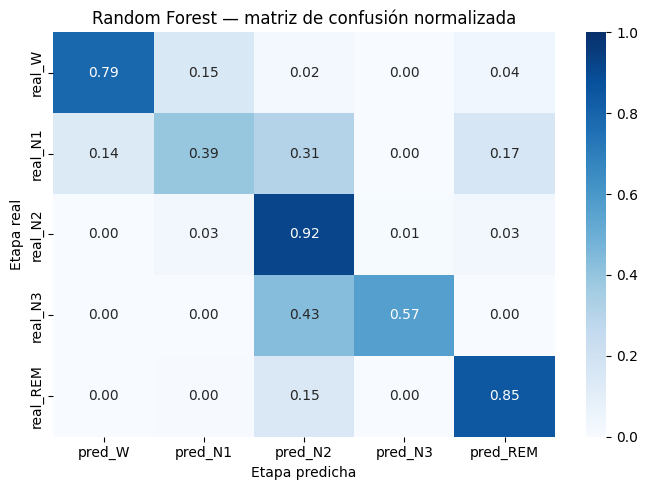


LightGBM
accuracy    0.7894
kappa       0.7100
f1_macro    0.7528

Métricas por estadio:
     precision  recall  f1-score  support
W       0.8792  0.7898    0.8321   1161.0
N1      0.5269  0.4664    0.4948    862.0
N2      0.7386  0.9093    0.8151   3868.0
N3      0.9602  0.6348    0.7643   2207.0
REM     0.8417  0.8744    0.8578   1831.0


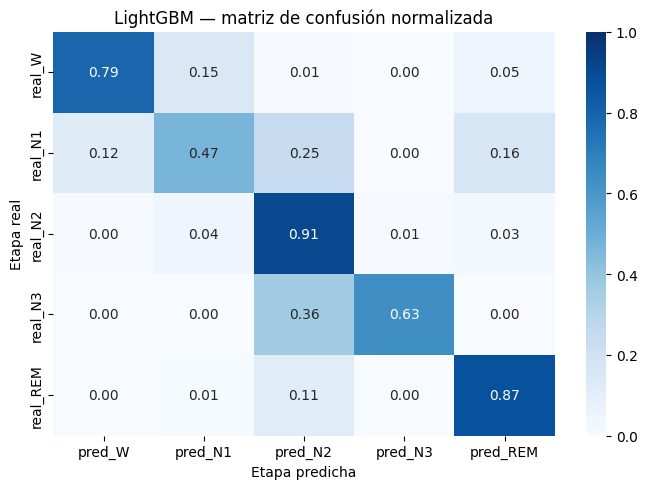

In [23]:
display(compare_evaluations(rf_evaluation, lgbm_evaluation).round(4))
display_evaluation(rf_evaluation)
display_evaluation(lgbm_evaluation)